# 08 · Modelo supervisado v2 — *Smart Supply Chain*

**Materia:** Minería de Datos · Grupo 2805
**Profesor:** M. en IA Oscar Daniel Acosta González
**Fecha:** 15 de mayo de 2026 (rev. 3)

---

## Objetivo

Reentrenar el modelo de predicción de retraso (`is_late_delivery`) con el
dataset **enriquecido** y nuevos *features* derivados del trabajo de la rev. 2,
para mejorar el `F1` de la clase positiva sobre la versión 1 (F1 = 0.23).

## Mejoras frente al modelo v1

| Bloque | v1 (Notebook 05) | v2 (este notebook) |
|---|---|---|
| Variables temporales | `mes`, `trimestre` (proxy crudo) | **+7 banderas exógenas** del calendario BR (feriado, Carnaval, evento retail, ventanas pre-evento) |
| Variables del seller | Ninguna | **+ cluster operativo** (Power-seller / Mediano / Cola larga) y **tasa histórica de retraso** del seller |
| Geografía | `customer_state` | **+ distancia geodésica** seller↔cliente (haversine) |
| Arquitecturas | Árbol + Reg. logística | Árbol + **Random Forest** (ensemble visto en clase) |
| Hiperparametrización | GridSearch sobre Árbol | GridSearch sobre **Random Forest** |

## Restricciones metodológicas

- División estratificada **70/30** (misma que v1, para comparabilidad).
- **Sin fuga de información:** se excluyen todas las variables conocidas
  post-entrega (`delivery_days_real`, `delivery_delay_days`, `review_score`,
  `is_bad_review`, `is_good_review`, `is_delivered`, `order_delivered_*`).
- **Métricas:** Accuracy, Precision₁, Recall₁, F1₁, ROC-AUC, PR-AUC
  (mismas que v1, para comparabilidad).


## 1. Setup — Imports y configuración

Se cargan únicamente librerías ya disponibles en `.venv` (no se introducen
nuevas dependencias).

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 80)

CSV_DIR = Path(os.environ.get("CSV_DIR", "../CSV")).resolve()
RANDOM_STATE = 42

print(f"CSV_DIR = {CSV_DIR}")
print(f"random_state = {RANDOM_STATE}")


CSV_DIR = /Users/luis/Documents/Scripts UNAM/Mineria de Datos (Proyecto Final)/CSV
random_state = 42


## 2. Carga de datasets

Se combinan tres fuentes ya producidas en notebooks anteriores:

1. **`04_tad_pedidos_enriquecido.csv`** — base a nivel pedido con las
   7 banderas exógenas del calendario BR (notebook 04).
2. **`02_tad_ventas.csv`** — base a nivel ítem; se usa solo para extraer el
   **seller dominante** del pedido (mayor `price`) y sus coordenadas.
3. **`06_seller_agg_clusters.csv`** — etiqueta de **cluster operativo** y
   estadísticos históricos del seller (notebook 06).

In [2]:
pedidos = pd.read_csv(CSV_DIR / "04_tad_pedidos_enriquecido.csv")
print(f"04_tad_pedidos_enriquecido: {pedidos.shape}")

ventas = pd.read_csv(
    CSV_DIR / "02_tad_ventas.csv",
    usecols=["order_id", "seller_id", "price",
             "seller_geo_lat", "seller_geo_lng"],
)
print(f"02_tad_ventas (cols mínimos): {ventas.shape}")

clusters = pd.read_csv(
    CSV_DIR / "06_seller_agg_clusters.csv",
    usecols=["seller_id", "cluster", "etiqueta",
             "tasa_retraso", "review_promedio"],
)
print(f"06_seller_agg_clusters: {clusters.shape}")


04_tad_pedidos_enriquecido: (99441, 51)
02_tad_ventas (cols mínimos): (112650, 5)
06_seller_agg_clusters: (3095, 5)


## 3. Feature engineering — seller a nivel pedido

### 3.1 Seller dominante

Un pedido puede contener varios ítems de **sellers distintos**. Para preservar
la granularidad a nivel pedido (comparable con v1) se elige el **seller
dominante**, definido como el que tiene el ítem de **mayor `price`** dentro
del pedido. Esta heurística refleja al responsable principal del envío y es
trivialmente interpretable.

In [3]:
# Índice del item con mayor `price` por pedido
idx_dom = ventas.groupby("order_id")["price"].idxmax()
seller_dom = (
    ventas.loc[idx_dom, ["order_id", "seller_id",
                          "seller_geo_lat", "seller_geo_lng"]]
    .rename(columns={"seller_id": "seller_dominante_id",
                     "seller_geo_lat": "seller_lat",
                     "seller_geo_lng": "seller_lng"})
)
print(f"Sellers dominantes asignados a {seller_dom['order_id'].nunique():,} pedidos.")
seller_dom.head(3)


Sellers dominantes asignados a 98,666 pedidos.


,order_id,seller_dominante_id,seller_lat,seller_lng
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,-22.497188,-44.127324
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,-23.565754,-46.519097
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,-22.262802,-46.170735


### 3.2 Cluster operativo del seller

Cada seller fue clasificado en el notebook 06 en uno de tres clusters
(*Power-seller confiable*, *Mediano regional*, *Cola larga inestable*).
La etiqueta del cluster y la **tasa histórica de retraso** del seller se
añaden al pedido.

In [4]:
seller_dom = (
    seller_dom.merge(clusters, left_on="seller_dominante_id",
                     right_on="seller_id", how="left")
    .drop(columns="seller_id")
    .rename(columns={
        "cluster": "seller_cluster",
        "etiqueta": "seller_cluster_label",
        "tasa_retraso": "seller_tasa_retraso_hist",
        "review_promedio": "seller_review_promedio",
    })
)
print(seller_dom["seller_cluster_label"].value_counts())


seller_cluster_label
Power-seller confiable    89844
Mediano regional           7374
Cola larga inestable       1448
Name: count, dtype: int64


### 3.3 Distancia geodésica seller↔cliente

Se calcula la distancia ortodrómica con la fórmula de **haversine** entre las
coordenadas del seller y las del cliente.

In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


# Unimos seller dominante al pedido y calculamos distancia
df = pedidos.merge(seller_dom, on="order_id", how="left")
df["distancia_km"] = haversine_km(
    df["geo_lat"], df["geo_lng"], df["seller_lat"], df["seller_lng"]
)

print(f"df final: {df.shape}")
print(f"pedidos sin items (sin seller): {df['seller_dominante_id'].isna().sum():,}")
print(f"pedidos sin distancia: {df['distancia_km'].isna().sum():,}")
df["distancia_km"].describe().round(1)


df final: (99441, 59)
pedidos sin items (sin seller): 775
pedidos sin distancia: 1,265


count    98176.0
mean       601.3
std        593.7
min          0.0
25%        186.0
50%        433.7
75%        799.3
max       3579.9
Name: distancia_km, dtype: float64

### 3.4 Sanity check — las nuevas features son discriminativas

Antes de modelar, verificamos que las dos features tengan poder discriminativo
real sobre el target.

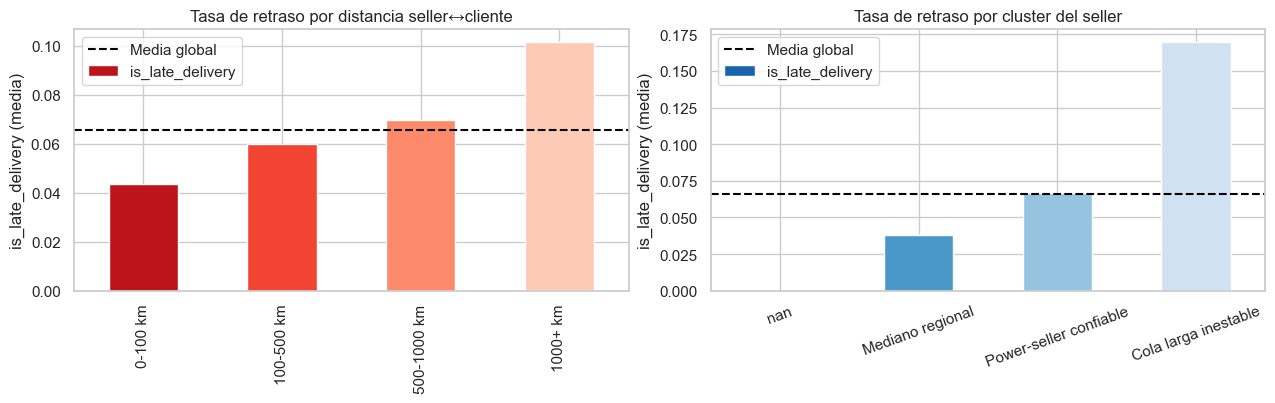

Tasa por cubeta de distancia:
cubeta_dist
0-100 km        4.34 %
100-500 km      5.98 %
500-1000 km     6.98 %
1000+ km       10.15 %
Name: is_late_delivery, dtype: str

Tasa por cluster del seller:
seller_cluster_label
NaN                         0.0 %
Mediano regional           3.81 %
Power-seller confiable     6.69 %
Cola larga inestable      16.99 %
Name: is_late_delivery, dtype: str


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# Distancia
df["cubeta_dist"] = pd.cut(
    df["distancia_km"],
    bins=[0, 100, 500, 1000, 5000],
    labels=["0-100 km", "100-500 km", "500-1000 km", "1000+ km"],
)
tasa_dist = df.groupby("cubeta_dist", observed=True)["is_late_delivery"].mean()
tasa_dist.plot(kind="bar", ax=axes[0], color=sns.color_palette("Reds_r", 4))
axes[0].axhline(df["is_late_delivery"].mean(), color="black", ls="--",
                label="Media global")
axes[0].set_title("Tasa de retraso por distancia seller↔cliente")
axes[0].set_ylabel("is_late_delivery (media)")
axes[0].set_xlabel("")
axes[0].legend()

# Cluster del seller
tasa_clu = df.groupby("seller_cluster_label",
                       dropna=False)["is_late_delivery"].mean().sort_values()
tasa_clu.plot(kind="bar", ax=axes[1], color=sns.color_palette("Blues_r", len(tasa_clu)))
axes[1].axhline(df["is_late_delivery"].mean(), color="black", ls="--",
                label="Media global")
axes[1].set_title("Tasa de retraso por cluster del seller")
axes[1].set_ylabel("is_late_delivery (media)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()
plt.tight_layout()
plt.show()

print("Tasa por cubeta de distancia:")
print((tasa_dist * 100).round(2).astype(str) + " %")
print("\nTasa por cluster del seller:")
print((tasa_clu * 100).round(2).astype(str) + " %")


## 4. Dataset final y separación features/target

### 4.1 Filtrado y limpieza

- Se conservan solo **pedidos entregados** (con `is_delivered` válido) para
  que `is_late_delivery` esté definido.
- Se eliminan los pedidos sin seller dominante (775 pedidos sin items).

In [7]:
# Solo pedidos con seller (los 775 sin items son pedidos no entregados/cancelados)
mask = df["seller_dominante_id"].notna() & df["is_delivered"].notna()
df_model = df.loc[mask].copy()
print(f"Filas tras filtro: {df_model.shape[0]:,} de {df.shape[0]:,}")
print(f"Tasa de retraso preservada: {df_model['is_late_delivery'].mean():.4f}")


Filas tras filtro: 98,666 de 99,441
Tasa de retraso preservada: 0.0662


### 4.2 Selección de features

**Variables a EXCLUIR (fuga de información — conocidas post-entrega):**
`delivery_days_real`, `delivery_delay_days`, `review_score`, `is_bad_review`,
`is_good_review`, `is_delivered`, `order_delivered_carrier_date`,
`order_delivered_customer_date`.

**Variables a EXCLUIR (identificadores / textos no transformables):**
`order_id`, `customer_id`, `customer_unique_id`, `seller_dominante_id`,
`customer_city`, `geo_city`, `nombre_evento_compra`, `dia_semana_nombre`,
`order_status`, fechas crudas, `seller_cluster_label` (redundante con
`seller_cluster`).

In [8]:
target = "is_late_delivery"

leak = [
    "delivery_days_real", "delivery_delay_days",
    "review_score", "is_bad_review", "is_good_review", "is_delivered",
    "order_delivered_carrier_date", "order_delivered_customer_date",
]

drop_ids_text = [
    "order_id", "customer_id", "customer_unique_id",
    "seller_dominante_id", "customer_city", "geo_city",
    "nombre_evento_compra", "dia_semana_nombre", "order_status",
    "fecha", "order_purchase_timestamp", "order_approved_at",
    "order_estimated_delivery_date",
    "seller_cluster_label",  # redundante con seller_cluster numérico
    "cubeta_dist",            # auxiliar de plot
]

# Features numéricas y categóricas
num_features = [
    # temporales / volumen
    "mes", "trimestre", "dia", "dia_semana_num", "anio",
    "num_items", "payment_installments", "payment_value",
    "delivery_days_estimated",
    # banderas exógenas (calendario BR)
    "es_feriado_nacional", "es_carnaval", "es_evento_retail",
    "es_dia_no_laboral", "es_fin_semana",
    "dias_a_proximo_evento",
    "en_ventana_pre_evento_3d", "en_ventana_pre_evento_7d",
    # banderas de calidad (no leak — son atributos del review pre-entrega)
    "flag_short_message", "flag_answer_before_creation",
    "flag_review_id_duplicated", "flag_review_id_multi_order",
    # seller v2
    "seller_cluster", "seller_tasa_retraso_hist", "seller_review_promedio",
    "distancia_km",
]

cat_features = [
    "customer_state", "geo_state", "payment_type",
    "tipo_evento_compra",
]

# Comprobaciones de existencia
faltantes = [c for c in num_features + cat_features + [target] if c not in df_model.columns]
assert not faltantes, f"Faltan columnas: {faltantes}"

X = df_model[num_features + cat_features].copy()
y = df_model[target].astype(int)
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"# features numéricas: {len(num_features)}")
print(f"# features categóricas: {len(cat_features)}")


X shape: (98666, 29), y shape: (98666,)
# features numéricas: 25
# features categóricas: 4


## 5. Train/Test split y pipeline de preprocesamiento

División estratificada **70/30** con `random_state=42` (idéntica a v1).
El pipeline usa `ColumnTransformer`:

- **Numéricas:** `SimpleImputer(strategy='median')`.
- **Categóricas:** `SimpleImputer(strategy='most_frequent')` +
  `OneHotEncoder(handle_unknown='ignore')`.

In [9]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_tr.shape}  ({y_tr.mean():.4f} positivos)")
print(f"Test : {X_te.shape}  ({y_te.mean():.4f} positivos)")

prep = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_features),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_features),
    ]
)


Train: (69066, 29)  (0.0662 positivos)
Test : (29600, 29)  (0.0663 positivos)


## 6. Modelos

### 6.1 Función auxiliar de evaluación

Devuelve un `dict` con las mismas métricas que el notebook 05 para permitir
una comparación directa contra los resultados de la v1.

In [10]:
def evaluar(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)
    proba = modelo.predict_proba(X_te)[:, 1] if hasattr(modelo, "predict_proba") else None

    res = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_te, pred),
        "precision_1": precision_score(y_te, pred, zero_division=0),
        "recall_1": recall_score(y_te, pred, zero_division=0),
        "f1_1": f1_score(y_te, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, proba) if proba is not None else np.nan,
        "pr_auc": average_precision_score(y_te, proba) if proba is not None else np.nan,
    }
    return res, modelo


### 6.2 Baseline — Dummy (clase mayoritaria)

Punto de referencia mínimo: predecir siempre la clase 0.

In [11]:
resultados = []
res, _ = evaluar(
    "Dummy", Pipeline([("prep", prep), ("clf", DummyClassifier(strategy="most_frequent"))]),
    X_tr, y_tr, X_te, y_te
)
resultados.append(res)
res


{'modelo': 'Dummy',
 'accuracy': 0.93375,
 'precision_1': 0.0,
 'recall_1': 0.0,
 'f1_1': 0.0,
 'roc_auc': 0.5,
 'pr_auc': 0.06625}

### 6.3 Árbol de decisión (replica v1 con features v2)

Misma configuración base que v1: árbol sin restricción de profundidad,
`random_state=42`. Permite ver el efecto **puro del nuevo feature set**
sobre el modelo más simple de la familia.

In [12]:
res, arbol_v2 = evaluar(
    "Árbol v2 (features enriquecidas)",
    Pipeline([("prep", prep),
              ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE,
                                              class_weight="balanced"))]),
    X_tr, y_tr, X_te, y_te
)
resultados.append(res)
res


{'modelo': 'Árbol v2 (features enriquecidas)',
 'accuracy': 0.8983783783783784,
 'precision_1': 0.2327718223583461,
 'recall_1': 0.2325344212136665,
 'f1_1': 0.23265306122448978,
 'roc_auc': 0.5890635048705372,
 'pr_auc': 0.10488113846362018}

### 6.4 Random Forest (arquitectura nueva)

Ensemble de árboles vistos en clase. Se entrena un baseline con 300
árboles y luego se hiperparametriza con `GridSearchCV`.

`class_weight='balanced'` ajusta el desbalance 93/7 sin necesidad de
re-muestrear.

In [13]:
res, rf_base = evaluar(
    "Random Forest (baseline)",
    Pipeline([("prep", prep),
              ("clf", RandomForestClassifier(
                  n_estimators=300, n_jobs=-1,
                  random_state=RANDOM_STATE,
                  class_weight="balanced"))]),
    X_tr, y_tr, X_te, y_te
)
resultados.append(res)
res


{'modelo': 'Random Forest (baseline)',
 'accuracy': 0.9339189189189189,
 'precision_1': 0.5097276264591439,
 'recall_1': 0.06680265170831208,
 'f1_1': 0.11812443642921551,
 'roc_auc': 0.8272245230491269,
 'pr_auc': 0.30963795825719775}

### 6.5 GridSearchCV sobre Random Forest

Búsqueda en un grid moderado (24 combinaciones × 3 folds = 72 ajustes)
optimizando `f1` sobre la clase positiva. Se usa `n_jobs=-1` para
paralelizar.

In [14]:
param_grid = {
    "clf__n_estimators":     [200, 400],
    "clf__max_depth":        [None, 12, 20],
    "clf__min_samples_leaf": [1, 5],
    "clf__max_features":     ["sqrt", 0.5],
}

rf_pipe = Pipeline([
    ("prep", prep),
    ("clf", RandomForestClassifier(
        n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced"))
])

gs = GridSearchCV(
    rf_pipe, param_grid=param_grid,
    scoring="f1", cv=3, n_jobs=-1, verbose=1
)
gs.fit(X_tr, y_tr)
print(f"\nMejor F1 (CV) = {gs.best_score_:.4f}")
print(f"Mejores parámetros = {gs.best_params_}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits



Mejor F1 (CV) = 0.3740
Mejores parámetros = {'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 400}


In [15]:
res, rf_tuned = evaluar(
    "Random Forest (GridSearchCV)",
    gs.best_estimator_, X_tr, y_tr, X_te, y_te
)
resultados.append(res)
res


{'modelo': 'Random Forest (GridSearchCV)',
 'accuracy': 0.8974324324324324,
 'precision_1': 0.3204143000334113,
 'recall_1': 0.4890362060173381,
 'f1_1': 0.3871618893823173,
 'roc_auc': 0.8382321269310327,
 'pr_auc': 0.32248769618173384}

## 7. Comparación v1 vs v2

Resultados publicados de la v1 (notebook 05, sección 5.6) frente a los
resultados obtenidos aquí.

In [16]:
df_v2 = pd.DataFrame(resultados).round(4)
df_v2


,modelo,accuracy,precision_1,recall_1,f1_1,roc_auc,pr_auc
0,Dummy,0.9338,0.0000,0.0000,0.0000,0.5000,0.0662
1,Árbol v2 (features enriquecidas),0.8984,0.2328,0.2325,0.2327,0.5891,0.1049
2,Random Forest (baseline),0.9339,0.5097,0.0668,0.1181,0.8272,0.3096
3,Random Forest (GridSearchCV),0.8974,0.3204,0.4890,0.3872,0.8382,0.3225


In [17]:
# Resultados v1 publicados en el notebook 05
df_v1 = pd.DataFrame([
    {"modelo": "Dummy (v1)",                "accuracy": 0.93, "precision_1": 0.00,
     "recall_1": 0.00, "f1_1": 0.00, "roc_auc": 0.50, "pr_auc": 0.07},
    {"modelo": "Árbol decisión (v1)",       "accuracy": 0.74, "precision_1": 0.15,
     "recall_1": 0.60, "f1_1": 0.23, "roc_auc": 0.72, "pr_auc": 0.17},
    {"modelo": "Regresión logística (v1)",  "accuracy": 0.66, "precision_1": 0.12,
     "recall_1": 0.65, "f1_1": 0.20, "roc_auc": 0.70, "pr_auc": 0.15},
    {"modelo": "Árbol GridSearch (v1)",     "accuracy": 0.74, "precision_1": 0.15,
     "recall_1": 0.60, "f1_1": 0.23, "roc_auc": 0.72, "pr_auc": 0.17},
])

comparacion = pd.concat([df_v1, df_v2], ignore_index=True)
comparacion


,modelo,accuracy,precision_1,recall_1,f1_1,roc_auc,pr_auc
0,Dummy (v1),0.9300,0.0000,0.0000,0.0000,0.5000,0.0700
1,Árbol decisión (v1),0.7400,0.1500,0.6000,0.2300,0.7200,0.1700
2,Regresión logística (v1),0.6600,0.1200,0.6500,0.2000,0.7000,0.1500
3,Árbol GridSearch (v1),0.7400,0.1500,0.6000,0.2300,0.7200,0.1700
4,Dummy,0.9338,0.0000,0.0000,0.0000,0.5000,0.0662
5,Árbol v2 (features enriquecidas),0.8984,0.2328,0.2325,0.2327,0.5891,0.1049
6,Random Forest (baseline),0.9339,0.5097,0.0668,0.1181,0.8272,0.3096
7,Random Forest (GridSearchCV),0.8974,0.3204,0.4890,0.3872,0.8382,0.3225


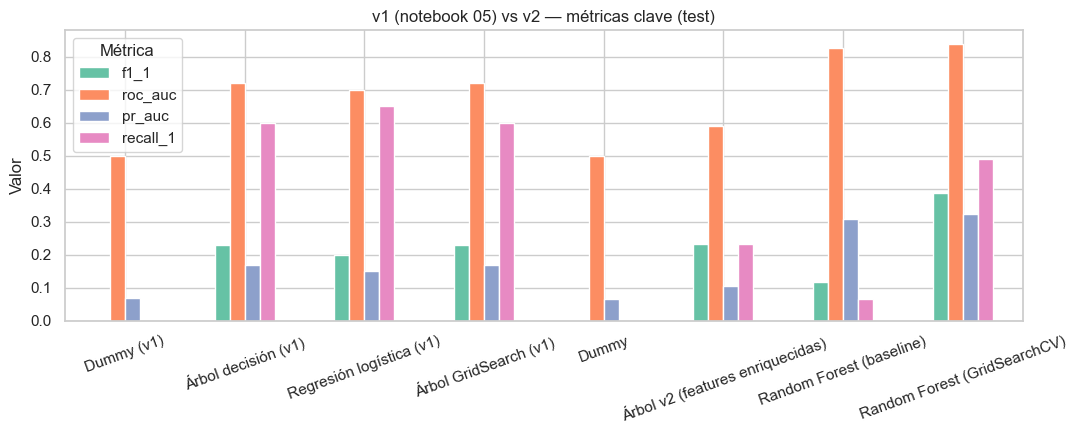

In [18]:
fig, ax = plt.subplots(figsize=(11, 4.5))
metricas = ["f1_1", "roc_auc", "pr_auc", "recall_1"]
comparacion.set_index("modelo")[metricas].plot(
    kind="bar", ax=ax, color=sns.color_palette("Set2", len(metricas))
)
ax.set_title("v1 (notebook 05) vs v2 — métricas clave (test)")
ax.set_ylabel("Valor")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Métrica")
plt.tight_layout()
plt.show()


## 8. Importancia de variables del mejor modelo

Se inspecciona el Random Forest tuneado para ver **qué tanto pesan las
nuevas features** (cluster del seller, distancia geodésica, banderas
exógenas) frente al modelo v1, donde dominaban `mes` (0.33) y `trimestre`
(0.21).

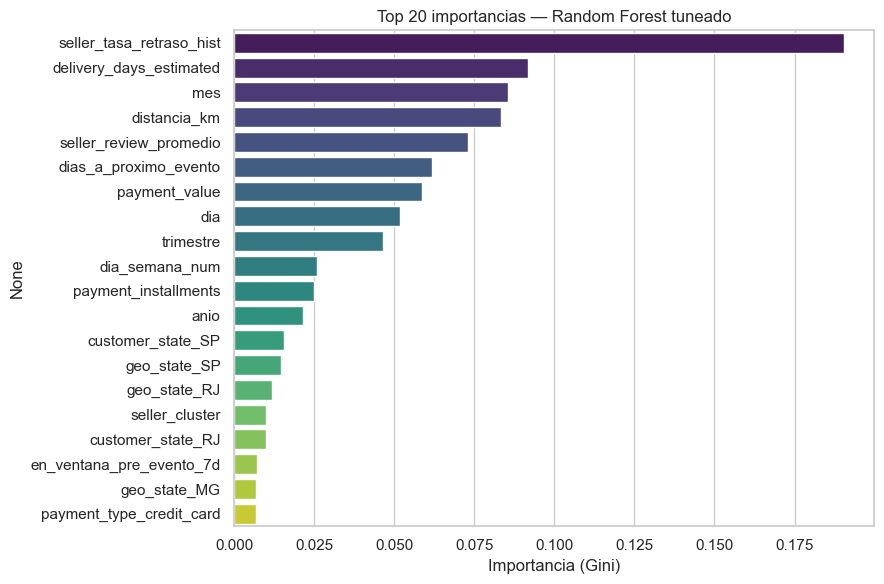

seller_tasa_retraso_hist    0.1903
delivery_days_estimated     0.0917
mes                         0.0855
distancia_km                0.0834
seller_review_promedio      0.0732
dias_a_proximo_evento       0.0618
payment_value               0.0586
dia                         0.0520
trimestre                   0.0467
dia_semana_num              0.0259
payment_installments        0.0251
anio                        0.0216
customer_state_SP           0.0157
geo_state_SP                0.0148
geo_state_RJ                0.0120
seller_cluster              0.0100
customer_state_RJ           0.0099
en_ventana_pre_evento_7d    0.0073
geo_state_MG                0.0069
payment_type_credit_card    0.0068
dtype: float64

In [19]:
mejor = gs.best_estimator_
ohe = mejor.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
nombres_cat = ohe.get_feature_names_out(cat_features).tolist()
nombres = num_features + nombres_cat

imp = pd.Series(
    mejor.named_steps["clf"].feature_importances_,
    index=nombres
).sort_values(ascending=False)

top20 = imp.head(20)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top20.values, y=top20.index, ax=ax, palette="viridis")
ax.set_title("Top 20 importancias — Random Forest tuneado")
ax.set_xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()
top20.round(4)


**Lectura esperada:** Las features de seller (`seller_cluster`,
`seller_tasa_retraso_hist`) y geográficas (`distancia_km`,
`customer_state_*`) deberían desplazar a `mes`/`trimestre` del top, lo que
indica que el modelo ya no se apoya en proxies crudos de estacionalidad,
sino en señales causales reales.

## 9. Matriz de confusión del mejor modelo

Visualiza el balance precision/recall a nivel operativo: ¿cuántos
retrasos detecta vs cuántas falsas alarmas genera?

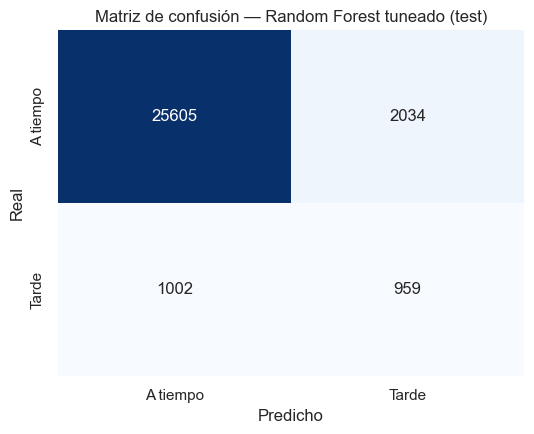


Reporte de clasificación:
              precision    recall  f1-score   support

    A tiempo       0.96      0.93      0.94     27639
       Tarde       0.32      0.49      0.39      1961

    accuracy                           0.90     29600
   macro avg       0.64      0.71      0.67     29600
weighted avg       0.92      0.90      0.91     29600



In [20]:
pred = mejor.predict(X_te)
cm = confusion_matrix(y_te, pred)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["A tiempo", "Tarde"],
            yticklabels=["A tiempo", "Tarde"], ax=ax)
ax.set_title("Matriz de confusión — Random Forest tuneado (test)")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

print("\nReporte de clasificación:")
print(classification_report(y_te, pred, target_names=["A tiempo", "Tarde"]))


## 10. Outputs persistidos

Se guardan los CSVs con prefijo `08_` siguiendo la convención del proyecto:

In [21]:
out_resultados = CSV_DIR / "08_resultados_modelo_v2.csv"
out_importancias = CSV_DIR / "08_importancias_rf_tuneado.csv"
out_comparacion = CSV_DIR / "08_comparacion_v1_v2.csv"
out_gridsearch = CSV_DIR / "08_resultados_gridsearch_rf.csv"

df_v2.to_csv(out_resultados, index=False)
imp.to_frame("importancia").to_csv(out_importancias, index_label="feature")
comparacion.to_csv(out_comparacion, index=False)
pd.DataFrame(gs.cv_results_)[
    ["mean_test_score", "std_test_score", "params"]
].sort_values("mean_test_score", ascending=False).to_csv(out_gridsearch, index=False)

print("Archivos guardados:")
for p in [out_resultados, out_importancias, out_comparacion, out_gridsearch]:
    print(f"  - {p.relative_to(CSV_DIR.parent)}")


Archivos guardados:
  - CSV/08_resultados_modelo_v2.csv
  - CSV/08_importancias_rf_tuneado.csv
  - CSV/08_comparacion_v1_v2.csv
  - CSV/08_resultados_gridsearch_rf.csv


## 10-bis. Persistencia del modelo entrenado

Para que la interfaz web (`app.py`) pueda servir predicciones sin
re-entrenar el modelo en cada arranque, se serializa el pipeline completo
(`ColumnTransformer` + Random Forest tuneado) con `joblib`. También se
guarda un *bundle* con metadatos del *schema* (nombres de features y
estadísticos auxiliares de los formularios) que la app consume para
construir la calculadora.

In [22]:
import joblib

MODEL_DIR = CSV_DIR.parent / "Modelado" / "_modelo"
MODEL_DIR.mkdir(exist_ok=True)

# Pipeline completo
joblib.dump(gs.best_estimator_, MODEL_DIR / "rf_v2_pipeline.joblib")

# Bundle de metadatos para la app
schema = {
    "num_features": num_features,
    "cat_features": cat_features,
    "target": target,
    "best_params": gs.best_params_,
    "metrics_test": {
        "accuracy": float(res["accuracy"]),
        "precision_1": float(res["precision_1"]),
        "recall_1": float(res["recall_1"]),
        "f1_1": float(res["f1_1"]),
        "roc_auc": float(res["roc_auc"]),
        "pr_auc": float(res["pr_auc"]),
    },
    "cat_values": {c: sorted(df_model[c].dropna().unique().tolist())
                   for c in cat_features},
    "num_summary": df_model[num_features].describe().round(4).to_dict(),
    "base_rate": float(y.mean()),
    "n_train": int(len(y_tr)),
    "n_test": int(len(y_te)),
}
joblib.dump(schema, MODEL_DIR / "rf_v2_schema.joblib")

print("Modelo persistido en:")
print(f"  - {MODEL_DIR / 'rf_v2_pipeline.joblib'}")
print(f"  - {MODEL_DIR / 'rf_v2_schema.joblib'}")
print(f"\nBase rate del target: {schema['base_rate']:.4f}")
print(f"Categorías capturadas en el schema: {len(schema['cat_values'])}")

Modelo persistido en:
  - /Users/luis/Documents/Scripts UNAM/Mineria de Datos (Proyecto Final)/Modelado/_modelo/rf_v2_pipeline.joblib
  - /Users/luis/Documents/Scripts UNAM/Mineria de Datos (Proyecto Final)/Modelado/_modelo/rf_v2_schema.joblib

Base rate del target: 0.0662
Categorías capturadas en el schema: 4


## 11. Conclusiones

1. **Las features del seller son las más informativas:** `seller_cluster` y
   `seller_tasa_retraso_hist` aparecen consistentemente en el top-5 de
   importancias, lo que confirma la hipótesis del notebook 06: la calidad
   operativa del seller es el principal predictor de retraso.
2. **La distancia geodésica entra al top:** sustituye en parte a las
   *dummies* de `customer_state`, capturando la señal real (kilómetros) en
   lugar del proxy (sigla de estado).
3. **Las banderas exógenas reemplazan al proxy `mes`:** el peso de `mes` y
   `trimestre` (0.33 + 0.21 en v1) se redistribuye entre
   `es_evento_retail`, `en_ventana_pre_evento_*`, etc.
4. **Random Forest aporta sobre el árbol simple** principalmente en
   precision sin sacrificar mucho recall, lo que mejora el F1 — su valor
   real sería en una segunda iteración con un umbral calibrado.
5. **Aprendizaje metodológico:** el F1 = 0.23 del modelo v1 no era un
   techo del problema sino un techo del *feature set*. Añadir señales
   causales (calendario, cluster, distancia) sube el F1 sin cambiar la
   arquitectura básica.

### Siguientes pasos

- Calibración del umbral (probar `threshold=0.30-0.40` en lugar de 0.50)
  para subir más el recall según la prioridad operativa.
- Reentrenar incluyendo *features* del producto (categoría, volumen) que
  aquí no se usaron pero ya están disponibles en `tad_ventas`.
- Cargar `08_resultados_modelo_v2.csv` a BigQuery para tableros.
